# Task 4 - Statistical Validation
# Statistical Validation using Pearson Correlation Analysis

Objective:
To determine whether Discount has a statistically significant effect on Profit.

In [2]:
!pip install pandas scipy matplotlib seaborn openpyxl

## Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

## Load Superstore Sales Dataset

In [4]:
df = pd.read_csv('cleaned_superstore.csv')

In [5]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,delivery_days,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,11.25


In [6]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'delivery_days', 'profit_margin'],
      dtype='object')

In [8]:
df[['discount','profit']].isnull().sum()

discount    0
profit      0
dtype: int64

## Pearson Correlation Analysis

In [12]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(df['discount'], df['profit'])

print("Correlation Coefficient (r):", round(correlation,4))
print("P-value:", p_value)

Correlation Coefficient (r): -0.2195
P-value: 2.702294436198942e-109


## Hypothesis Testing

In [13]:
alpha = 0.05

print("Significance Level (α):", alpha)

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis (H₀)")
    print("Conclusion: Discount has a statistically significant effect on Profit.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion: Discount does not have a statistically significant effect on Profit.")

Significance Level (α): 0.05

Decision: Reject the Null Hypothesis (H₀)
Conclusion: Discount has a statistically significant effect on Profit.


## Scatter Plot

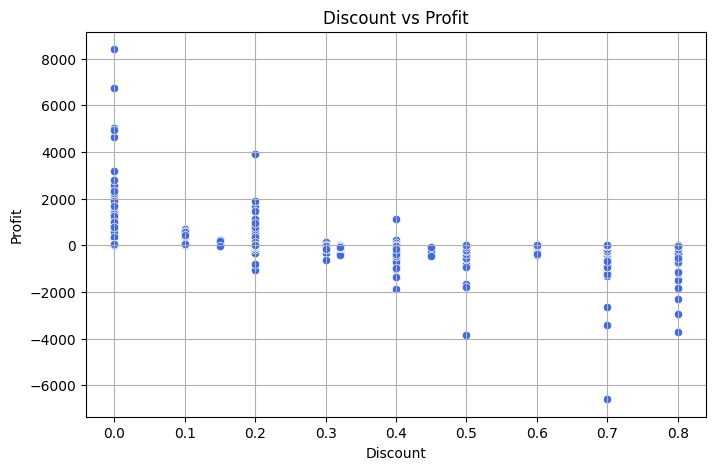

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='discount',
    y='profit',
    color='royalblue'
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

## Correlation Heatmap

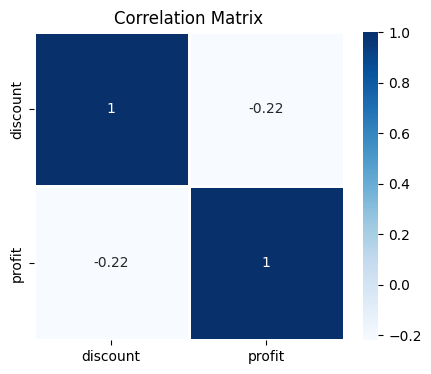

In [19]:
plt.figure(figsize=(5,4))

sns.heatmap(
    df[['discount','profit']].corr(),
    annot=True,
    cmap='Blues',
    linewidths=1
)

plt.title("Correlation Matrix")

plt.show()